In [1]:
import pandas as pd
import numpy as np

import tubesml as tml

import matplotlib.pyplot as plt
%matplotlib inline

from source.aggregated_stats import process_details, full_stats
from source.add_info import add_seed, add_quality, add_stage, add_elo
from source.make_train_test import make_teams_target, make_training_data


In [2]:
men_reg = pd.read_csv('data/march-machine-learning-mania-2026/MRegularSeasonDetailedResults.csv')
men_reg_details = process_details(men_reg)
men_reg = full_stats(men_reg_details)
men_reg = add_seed('data/march-machine-learning-mania-2026/MNCAATourneySeeds.csv', men_reg)
men_reg = add_elo(men_reg_details, men_reg)

men_reg.head()

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`


,Season,TeamID,Ast,Ast_TO_ratio,Ast_TO_ratio_diff,Ast_diff,Away,Blk,Blk_diff,DR,...,FT_perc,FGM_no_ast_perc,True_shooting_perc,Opp_True_shooting_perc,Eff_shooting_perc,Opp_eff_shooting_perc,OT_win_perc,Seed,region,elo
0,2003,1102,13.000000,1.375047,0.605180,3.857143,0.107143,1.785714,0.214286,16.821429,...,0.651357,0.320896,0.605015,0.559937,0.579443,0.510522,0.00,NaN,NaN,974.197367
1,2003,1103,14.723457,1.324471,0.263213,-0.184362,0.148148,2.297119,-0.453498,19.255967,...,0.737787,0.439497,0.585573,0.585414,0.534984,0.545500,0.75,NaN,NaN,983.942090
2,2003,1104,12.059524,0.992381,0.044656,0.420635,0.142857,3.777778,0.607143,23.853175,...,0.710126,0.496271,0.521757,0.515397,0.475827,0.476032,1.00,10.0,Y,1111.862966
3,2003,1105,14.269231,0.861951,-0.074315,-1.292308,0.076923,2.033333,-2.105128,22.625641,...,0.706221,0.403920,0.503488,0.550348,0.457074,0.511879,0.00,NaN,NaN,634.480645
4,2003,1106,11.619048,0.723184,-0.129573,-0.103175,0.178571,3.126984,-0.027778,23.761905,...,0.645677,0.501532,0.508457,0.505351,0.478940,0.451355,1.00,NaN,NaN,781.068089


In [3]:
men_target_data = pd.read_csv('data/march-machine-learning-mania-2026/MNCAATourneyCompactResults.csv')
men_target_data = make_teams_target(men_target_data, "men")

In [4]:
men_training = make_training_data(men_reg, men_target_data)
men_training = add_stage(men_training)
men_training = add_quality(men_training, men_reg_details)
men_training  = men_training[men_training.DayNum >= 136]  # remove pre tourney 

men_training.head()

,Season,DayNum,Team1,Team2,target,target_points,T1_Loc,T2_Loc,ID,T1_Ast,...,stage_Round1,stage_Round2,stage_Round3,stage_Round4,stage_final,stage_finalfour,stage_impossible,T1_quality,T2_quality,delta_quality
1,2003,136,1112,1436,1,29,0,0,2003_1112_1436,17.488095,...,True,False,False,False,False,False,False,42.710561,0.650237,42.060324
2,2003,136,1113,1272,1,13,0,0,2003_1113_1272,15.448276,...,True,False,False,False,False,False,False,7.704377,12.577559,-4.873181
3,2003,136,1141,1166,1,6,0,0,2003_1141_1166,15.620690,...,True,False,False,False,False,False,False,4.880807,13.600178,-8.719372
4,2003,136,1143,1301,1,2,0,0,2003_1143_1301,15.816092,...,True,False,False,False,False,False,False,10.200473,6.628850,3.571623
5,2003,136,1140,1163,0,-5,0,0,2003_1140_1163,13.372760,...,True,False,False,False,False,False,False,8.352330,8.473791,-0.121461


In [5]:
men_training.to_csv("data/processed/men_training.csv", index=False)

# Winning target

In [6]:
target = "target"
col_to_use = [c for c in men_training if "target" not in c and c != "ID" and "region" not in c] + [target]

df = men_training[col_to_use].copy()

df.head()

,Season,DayNum,Team1,Team2,T1_Loc,T2_Loc,T1_Ast,T1_Ast_TO_ratio,T1_Ast_TO_ratio_diff,T1_Ast_diff,...,stage_Round2,stage_Round3,stage_Round4,stage_final,stage_finalfour,stage_impossible,T1_quality,T2_quality,delta_quality,target
1,2003,136,1112,1436,0,0,17.488095,1.293488,0.268766,2.146825,...,False,False,False,False,False,False,42.710561,0.650237,42.060324,1
2,2003,136,1113,1272,0,0,15.448276,1.203241,0.234362,1.501916,...,False,False,False,False,False,False,7.704377,12.577559,-4.873181,1
3,2003,136,1141,1166,0,0,15.620690,0.876115,0.085721,3.827586,...,False,False,False,False,False,False,4.880807,13.600178,-8.719372,1
4,2003,136,1143,1301,0,0,15.816092,1.223071,0.068819,-0.065134,...,False,False,False,False,False,False,10.200473,6.628850,3.571623,1
5,2003,136,1140,1163,0,0,13.372760,1.089304,0.287913,2.684588,...,False,False,False,False,False,False,8.352330,8.473791,-0.121461,0


In [7]:
to_drop = ["delta_def_rating_diff", "delta_impact_diff", "T1_def_rating_diff", "T2_def_rating_diff"]
df = df.drop(to_drop, axis=1)

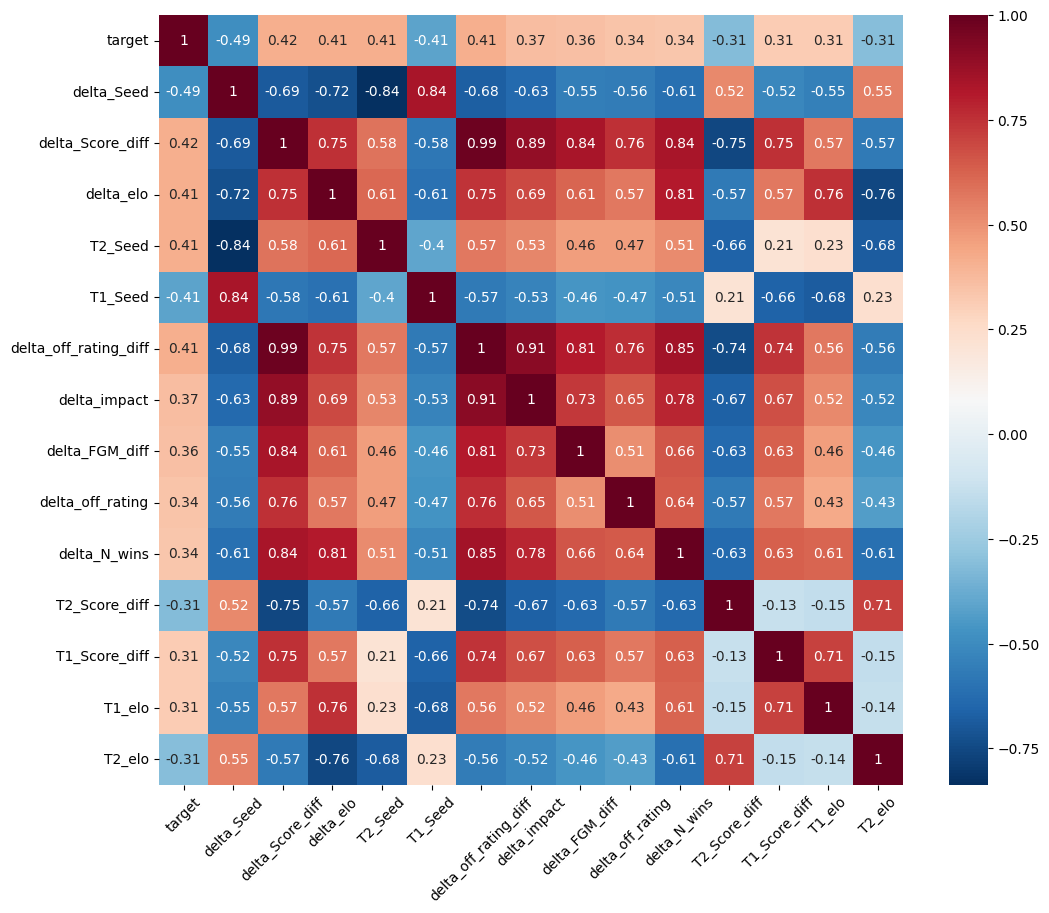

In [8]:
high_corr = tml.plot_correlations(data=df, target=target, limit=15, annot=True)

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN be

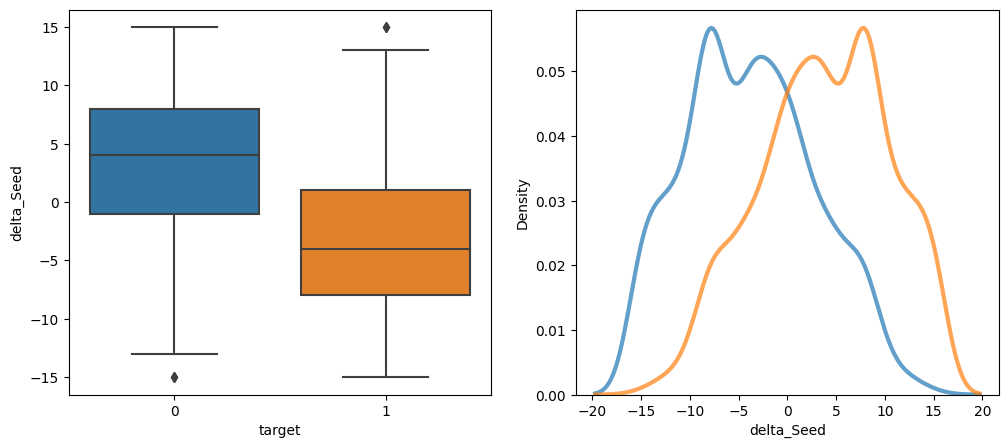

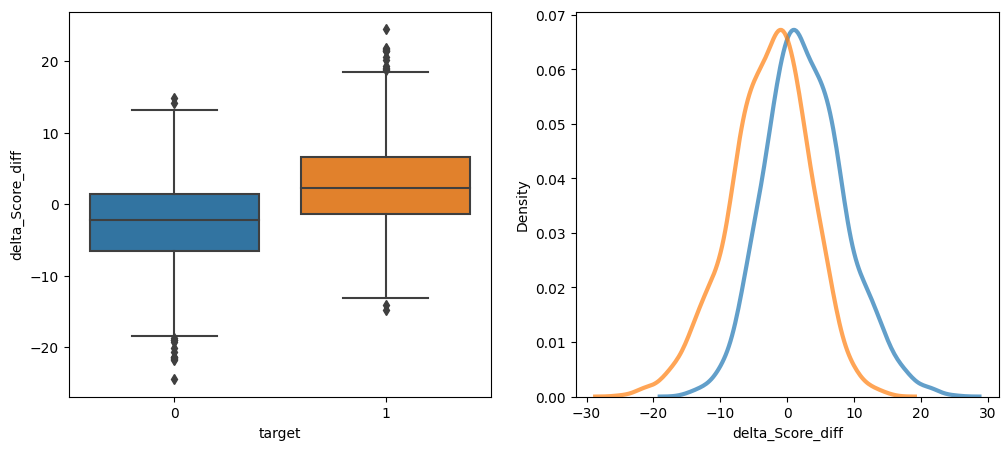

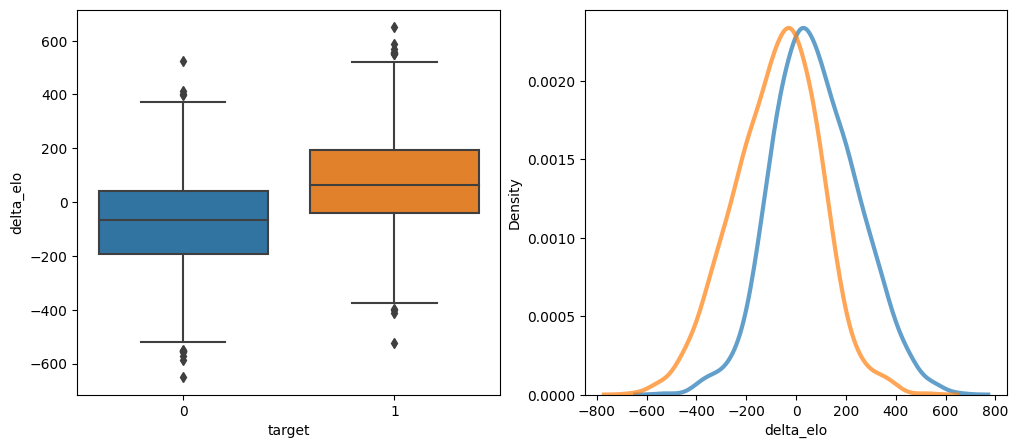

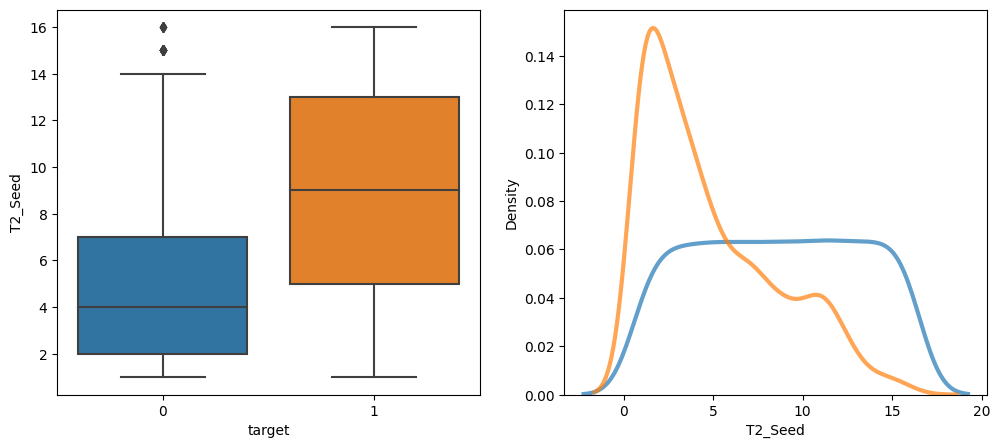

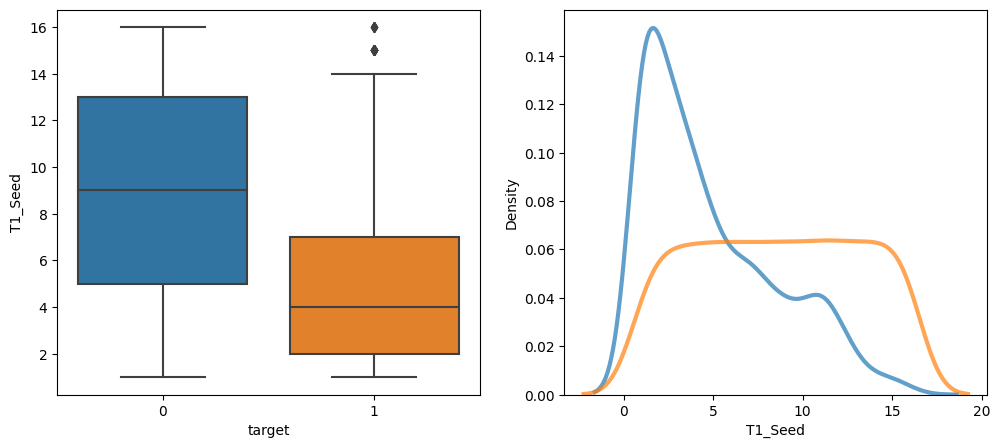

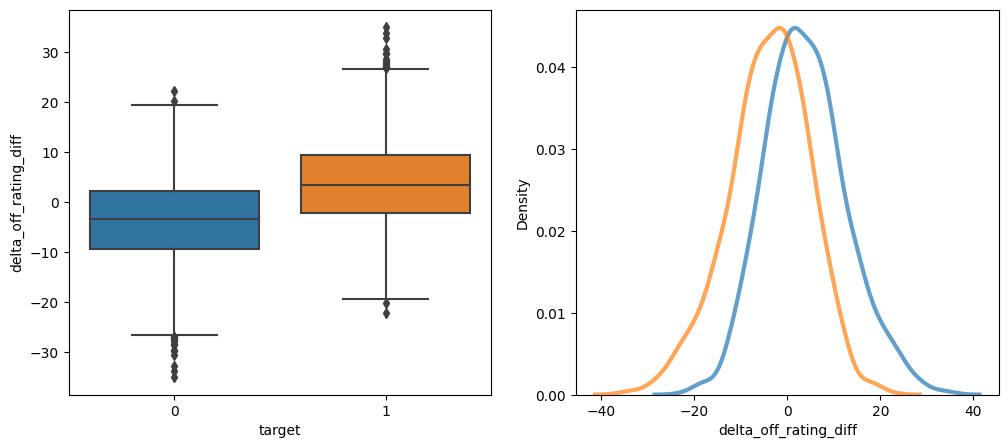

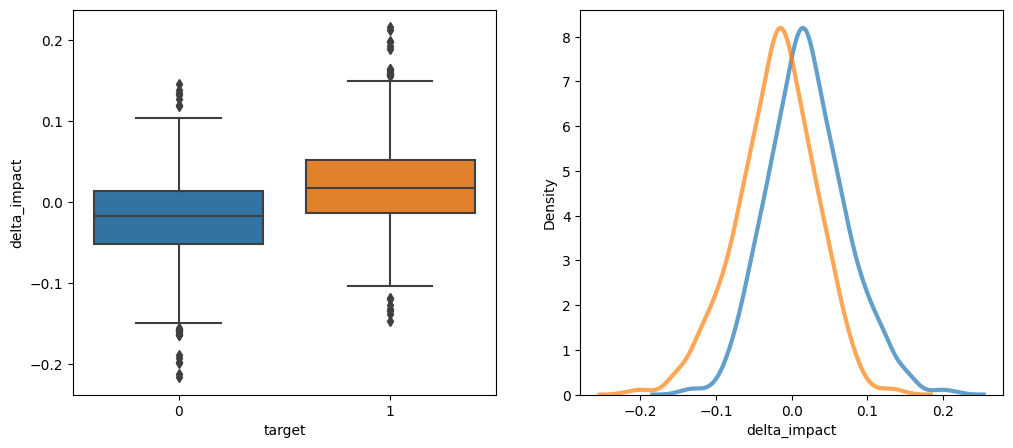

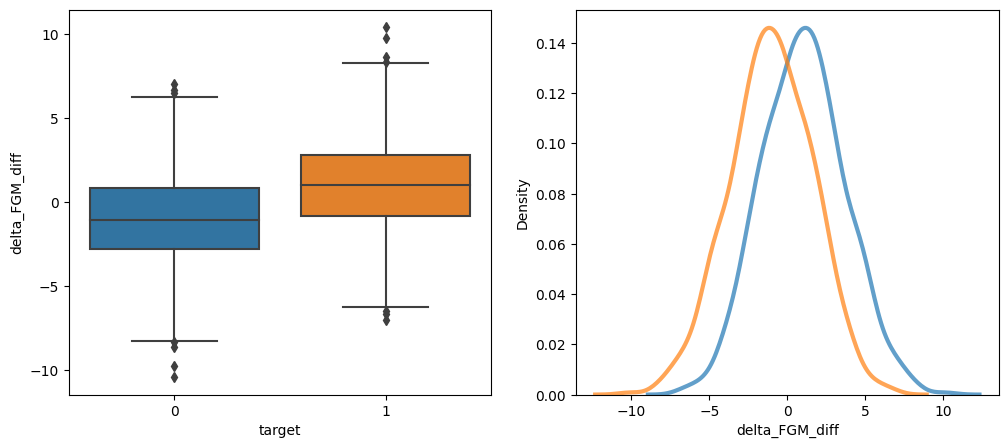

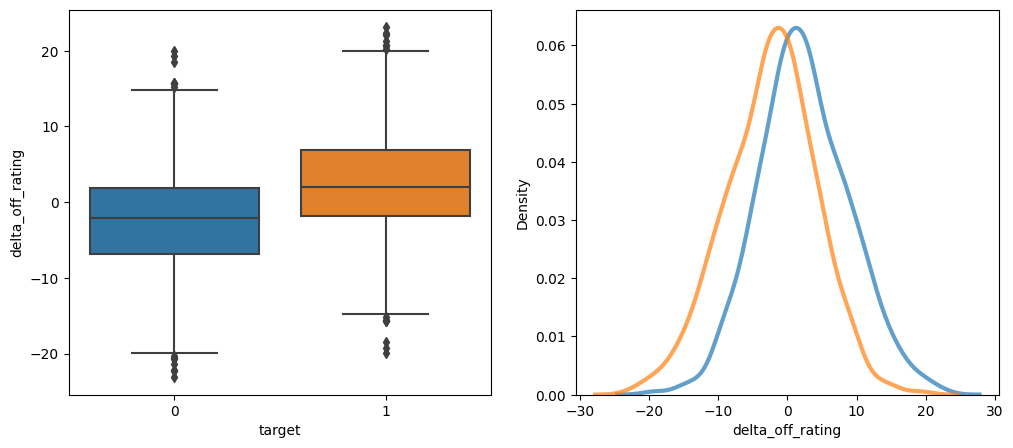

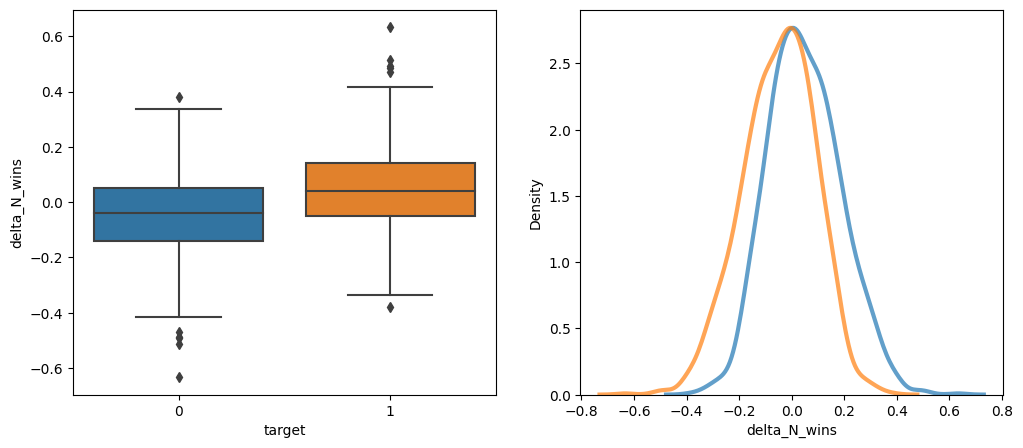

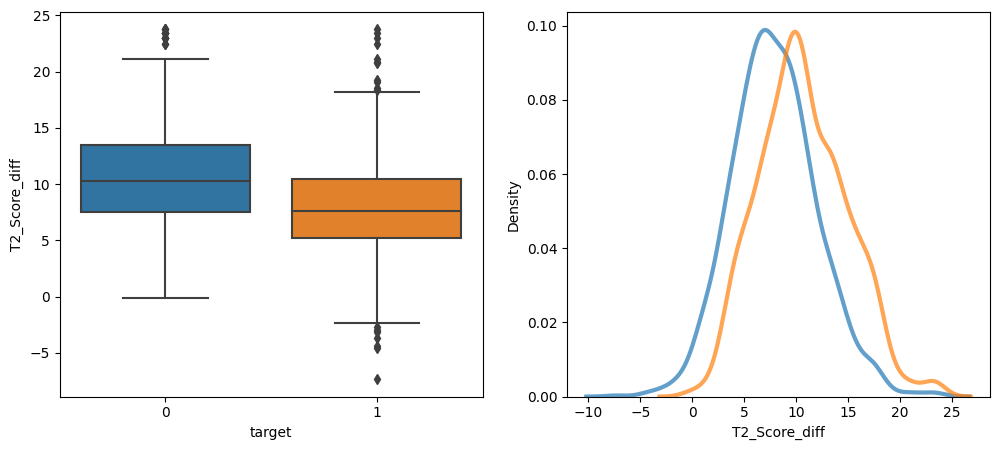

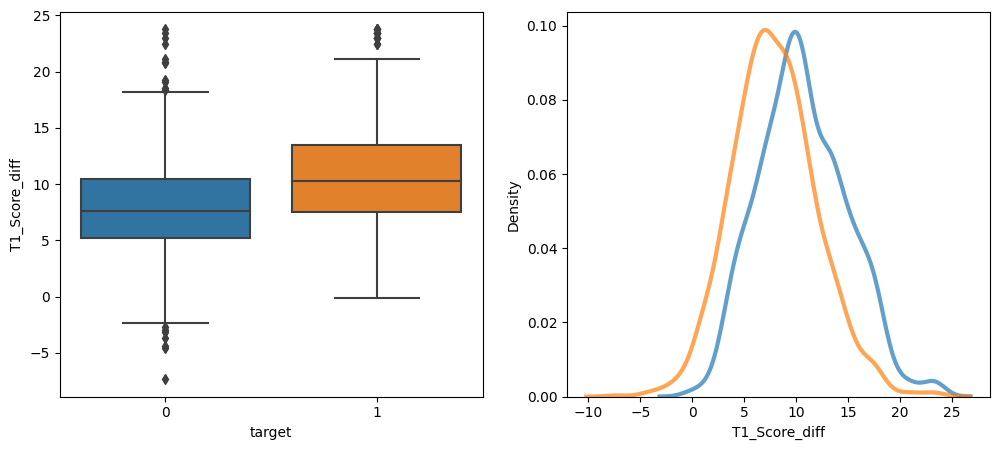

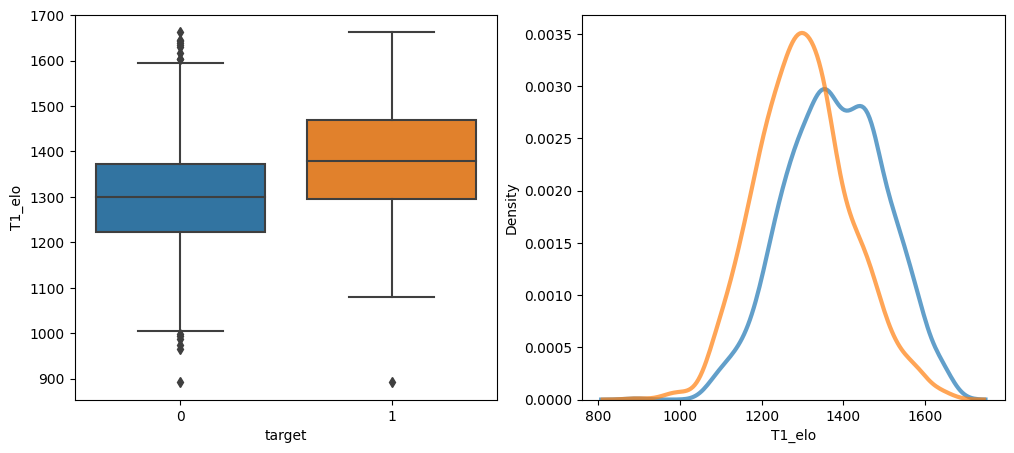

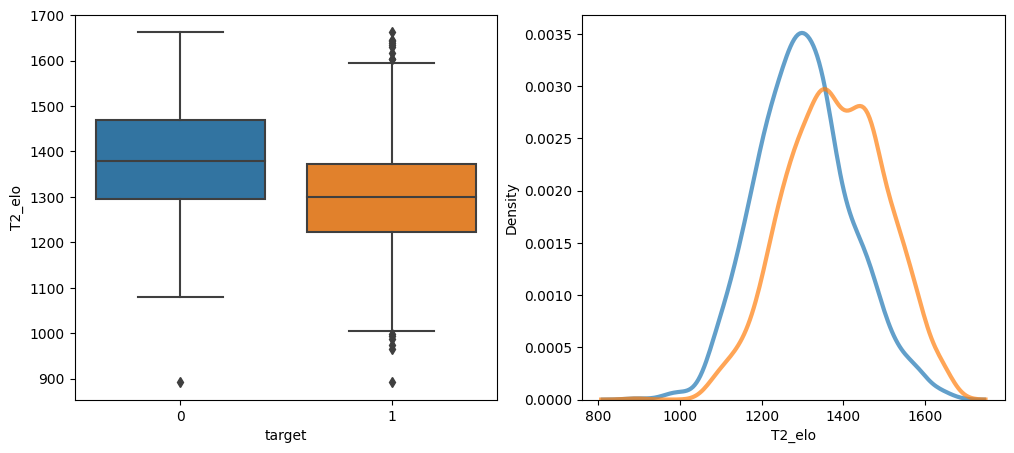

In [9]:
for col in high_corr.index:
    if col == target:
        continue
    tml.segm_target(data=df, cat=target, target=col)

# Point difference

In [10]:
target = "target_points"
col_to_use = [c for c in men_training if "target" not in c and c != "ID" and "region" not in c] + [target]

df = men_training[col_to_use].copy()
to_drop = ["delta_def_rating_diff", "delta_impact_diff", "T1_def_rating_diff", "T2_def_rating_diff"]
df = df.drop(to_drop, axis=1)

df.head()

,Season,DayNum,Team1,Team2,T1_Loc,T2_Loc,T1_Ast,T1_Ast_TO_ratio,T1_Ast_TO_ratio_diff,T1_Ast_diff,...,stage_Round2,stage_Round3,stage_Round4,stage_final,stage_finalfour,stage_impossible,T1_quality,T2_quality,delta_quality,target_points
1,2003,136,1112,1436,0,0,17.488095,1.293488,0.268766,2.146825,...,False,False,False,False,False,False,42.710561,0.650237,42.060324,29
2,2003,136,1113,1272,0,0,15.448276,1.203241,0.234362,1.501916,...,False,False,False,False,False,False,7.704377,12.577559,-4.873181,13
3,2003,136,1141,1166,0,0,15.620690,0.876115,0.085721,3.827586,...,False,False,False,False,False,False,4.880807,13.600178,-8.719372,6
4,2003,136,1143,1301,0,0,15.816092,1.223071,0.068819,-0.065134,...,False,False,False,False,False,False,10.200473,6.628850,3.571623,2
5,2003,136,1140,1163,0,0,13.372760,1.089304,0.287913,2.684588,...,False,False,False,False,False,False,8.352330,8.473791,-0.121461,-5


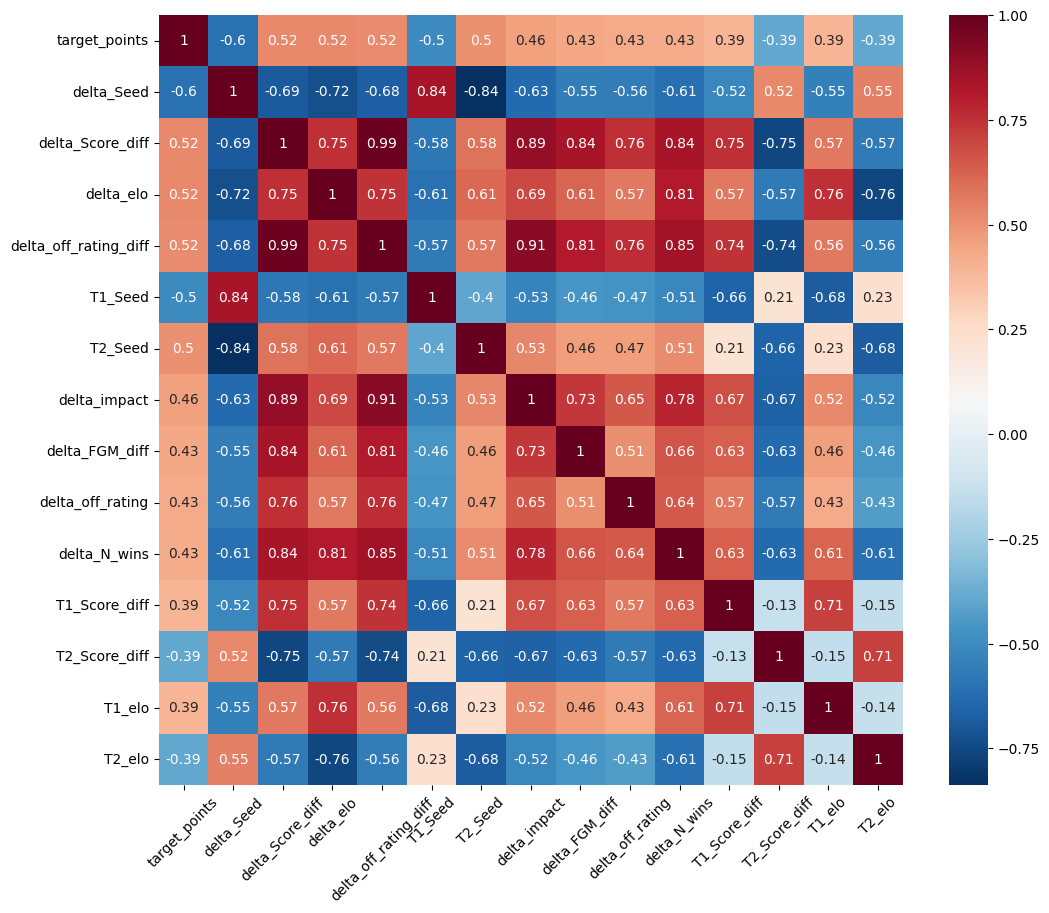

In [11]:
high_corr = tml.plot_correlations(data=df, target=target, limit=15, annot=True)

                       delta_Seed  delta_Score_diff  delta_elo  \
delta_Seed               1.000000         -0.692314  -0.723411   
delta_Score_diff        -0.692314          1.000000   0.750601   
delta_elo               -0.723411          0.750601   1.000000   
delta_off_rating_diff   -0.675293          0.985547   0.747602   
T1_Seed                  0.837555         -0.579851  -0.605896   
T2_Seed                 -0.837555          0.579851   0.605896   
delta_impact            -0.633803          0.891850   0.689679   
delta_FGM_diff          -0.553252          0.841843   0.613723   
delta_off_rating        -0.559289          0.755850   0.569217   
delta_N_wins            -0.614498          0.841528   0.812600   
T1_Score_diff           -0.521192          0.752826   0.565072   
T2_Score_diff            0.521192         -0.752826  -0.565072   
T1_elo                  -0.546401          0.566937   0.755312   
T2_elo                   0.546401         -0.566937  -0.755312   
target_poi

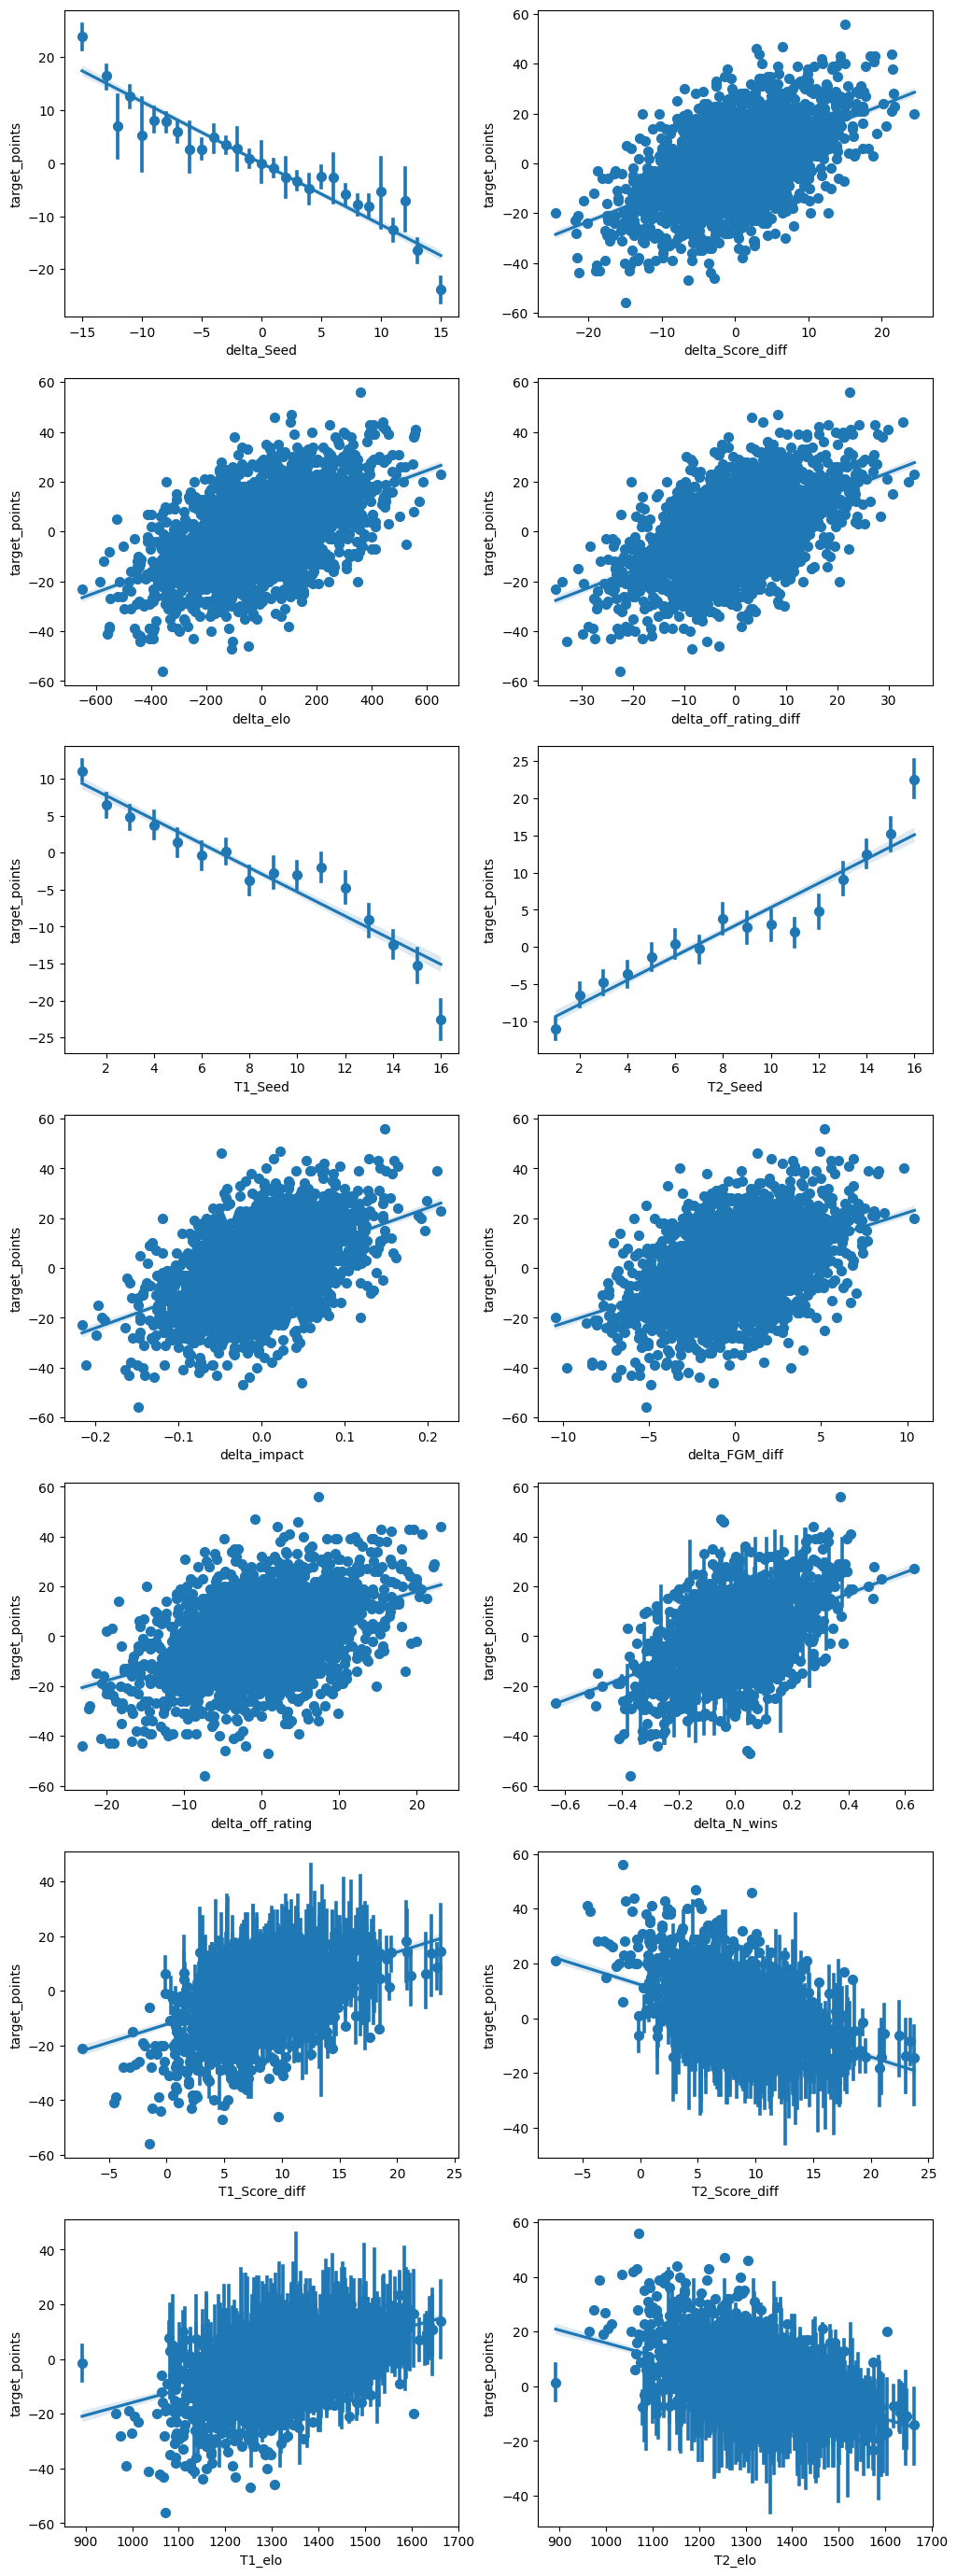

In [12]:
tml.corr_target(data=df, target=target, cols=[c for c in high_corr.index if c != target], x_estimator=np.mean)